# Capítulo 3 · De una neurona a una red

En el cuaderno anterior calculamos la salida de una neurona aislada. Ahora conectaremos varias neuronas para formar una red densa pequeña y seguiremos la información desde tres valores de entrada hasta una única salida.

Los pesos y los bias serán elegidos manualmente. El objetivo es comprender la arquitectura, las conexiones y la cantidad de parámetros, no entrenar el modelo ni evaluar su capacidad predictiva.


## Objetivos del cuaderno

Al finalizar este recorrido, deberías poder:

- representar los pesos de una capa densa mediante una matriz;
- calcular una propagación hacia adelante a través de varias capas;
- distinguir entrada, capas ocultas y salida;
- interpretar el ancho y la profundidad de una arquitectura;
- contar los pesos y los bias de cada capa;
- relacionar una implementación manual con la notación `Dense(...)` de Keras.


## Importación de librerías

Usaremos NumPy para los cálculos matriciales, Pandas para organizar algunos resultados y Matplotlib para representar la arquitectura.

No necesitamos entrenar un modelo ni descargar un dataset: trabajaremos con un único ejemplo numérico para que todas las transformaciones puedan observarse con claridad.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1. De tres entradas a una capa de cuatro neuronas

Nuestra red recibirá tres características. Podemos imaginarlas como los valores de un caso cualquiera ya preparado para ingresar al modelo:

$$
\mathbf{x} = [1{,}5,\ -2{,}0,\ 0{,}5]
$$

La primera capa oculta tendrá cuatro neuronas. Cada una estará conectada con las tres entradas, por lo que necesitaremos una matriz de pesos con cuatro filas y tres columnas. Cada fila reunirá los pesos de una neurona.


In [2]:
entradas = np.array([1.5, -2.0, 0.5])

pesos_capa_1 = np.array([
    [0.2,  0.8, -0.5],
    [0.5, -0.3,  0.1],
    [-0.4, 0.6,  0.9],
    [0.7,  0.2, -0.8],
])

bias_capa_1 = np.array([0.1, -0.2, 0.3, 0.0])

z_capa_1 = pesos_capa_1 @ entradas + bias_capa_1

print("Forma de las entradas:", entradas.shape)
print("Forma de la matriz de pesos:", pesos_capa_1.shape)
print("Forma del vector de bias:", bias_capa_1.shape)
print("Salidas antes de la activación:", np.round(z_capa_1, 2))


Forma de las entradas: (3,)
Forma de la matriz de pesos: (4, 3)
Forma del vector de bias: (4,)
Salidas antes de la activación: [-1.45  1.2  -1.05  0.25]


La matriz tiene forma **(4, 3)** porque contiene cuatro neuronas y tres pesos por neurona. El vector de bias contiene cuatro valores: uno para cada neurona de destino.

La operación matricial produce cuatro resultados: `[-1.45, 1.20, -1.05, 0.25]`. La capa recibió tres valores y construyó una nueva representación formada por cuatro valores.


Comprobemos el cálculo de la primera neurona por separado. Esta verificación permite conectar la operación matricial con la suma ponderada que estudiamos en el capítulo anterior.


In [3]:
productos_primera_neurona = entradas * pesos_capa_1[0]
resultado_explicito = productos_primera_neurona.sum() + bias_capa_1[0]

detalle_primera_neurona = pd.DataFrame(
    {
        "entrada": ["x1", "x2", "x3"],
        "valor": entradas,
        "peso": pesos_capa_1[0],
        "producto": productos_primera_neurona,
    }
)

display(detalle_primera_neurona)
print(f"Suma de productos y bias: {resultado_explicito:.2f}")
print(f"Primer valor de la operación matricial: {z_capa_1[0]:.2f}")


,entrada,valor,peso,producto
0,x1,1.5,0.2,0.30
1,x2,-2.0,0.8,-1.60
2,x3,0.5,-0.5,-0.25


Suma de productos y bias: -1.45
Primer valor de la operación matricial: -1.45


Los dos procedimientos producen **−1,45**. No estamos realizando un cálculo nuevo: la multiplicación entre una matriz y un vector permite calcular de una sola vez las sumas ponderadas de todas las neuronas de la capa.


## 2. Encadenar varias capas

Para que el ejemplo represente una red y no solamente una capa, enviaremos esas cuatro salidas a una segunda capa oculta de dos neuronas. Después conectaremos sus dos resultados con una neurona de salida.

Entre las capas aplicaremos ReLU, la activación que aparece en el ejemplo de Keras del capítulo. Por ahora solo usaremos su regla —conservar valores positivos y reemplazar los negativos por cero—. Su función dentro de la red y la comparación con otras activaciones corresponden al próximo capítulo.


In [4]:
def relu(valores):
    return np.maximum(0, valores)


pesos_capa_2 = np.array([
    [0.6, -0.4,  0.7, 0.2],
    [-0.3, 0.8, -0.5, 0.4],
])
bias_capa_2 = np.array([0.1, -0.2])

pesos_salida = np.array([[0.9, -0.6]])
bias_salida = np.array([0.05])

salida_capa_1 = relu(z_capa_1)
z_capa_2 = pesos_capa_2 @ salida_capa_1 + bias_capa_2
salida_capa_2 = relu(z_capa_2)
salida_final = pesos_salida @ salida_capa_2 + bias_salida

recorrido = pd.DataFrame(
    {
        "etapa": [
            "Entrada",
            "Capa oculta 1",
            "Capa oculta 2",
            "Capa de salida",
        ],
        "cantidad_de_valores": [3, 4, 2, 1],
        "valores": [
            np.round(entradas, 2).tolist(),
            np.round(salida_capa_1, 2).tolist(),
            np.round(salida_capa_2, 2).tolist(),
            np.round(salida_final, 3).tolist(),
        ],
    }
)

recorrido


,etapa,cantidad_de_valores,valores
0,Entrada,3,"[1.5, -2.0, 0.5]"
1,Capa oculta 1,4,"[0.0, 1.2, 0.0, 0.25]"
2,Capa oculta 2,2,"[0.0, 0.86]"
3,Capa de salida,1,[-0.466]


La información cambia de forma a medida que avanza:

**3 entradas → 4 valores → 2 valores → 1 salida**

La primera capa oculta produce `[0.0, 1.2, 0.0, 0.25]`; la segunda, `[0.0, 0.86]`; y la capa final entrega aproximadamente **−0,466**. Ese número no debe interpretarse como una predicción útil: la red puede realizar el cálculo, pero sus parámetros no fueron aprendidos a partir de datos.


La siguiente tabla muestra por separado la suma ponderada y la salida de cada capa oculta. Así podemos ver que una capa entrega sus valores transformados a la siguiente.


In [5]:
detalle_capas = pd.DataFrame(
    {
        "capa": ["Oculta 1", "Oculta 2"],
        "suma_ponderada_z": [
            np.round(z_capa_1, 2).tolist(),
            np.round(z_capa_2, 2).tolist(),
        ],
        "salida_entregada": [
            np.round(salida_capa_1, 2).tolist(),
            np.round(salida_capa_2, 2).tolist(),
        ],
    }
)

detalle_capas


,capa,suma_ponderada_z,salida_entregada
0,Oculta 1,"[-1.45, 1.2, -1.05, 0.25]","[0.0, 1.2, 0.0, 0.25]"
1,Oculta 2,"[-0.33, 0.86]","[0.0, 0.86]"


Los valores negativos de cada suma ponderada se convierten en cero después de ReLU; los positivos se conservan. La segunda capa no recibe las tres variables originales: recibe la representación de cuatro valores producida por la primera.

Este recorrido desde la entrada hasta la salida se denomina **propagación hacia adelante** o *forward pass*. No hay aprendizaje en este paso: los parámetros permanecen fijos mientras la red calcula su salida.


## 3. Visualizar la arquitectura

Representaremos la estructura **3 → 4 → 2 → 1**. Cada círculo corresponde a un valor de entrada o a una neurona, y cada línea muestra una conexión. Como todas las unidades de una capa se conectan con todas las de la siguiente, estamos trabajando con capas densas.


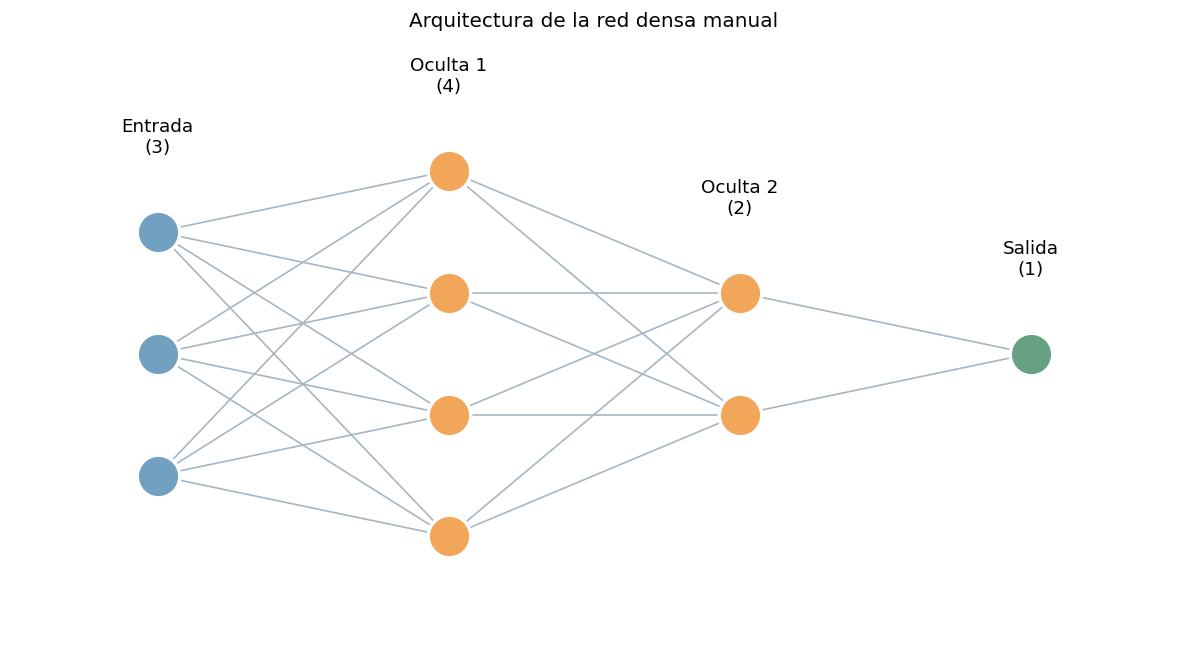

In [6]:
tamanos = [3, 4, 2, 1]
nombres = ["Entrada", "Oculta 1", "Oculta 2", "Salida"]
posiciones_x = np.arange(len(tamanos))

posiciones_capas = []
for x, cantidad in zip(posiciones_x, tamanos):
    posiciones_y = np.linspace(-(cantidad - 1) / 2, (cantidad - 1) / 2, cantidad)
    posiciones_capas.append([(x, y) for y in posiciones_y])

plt.figure(figsize=(10, 5.5))

for capa_actual, capa_siguiente in zip(posiciones_capas[:-1], posiciones_capas[1:]):
    for x1, y1 in capa_actual:
        for x2, y2 in capa_siguiente:
            plt.plot([x1, x2], [y1, y2], color="#A7B6C2", linewidth=1, zorder=1)

colores = ["#72A0C1", "#F2A65A", "#F2A65A", "#66A182"]
for x, posiciones, nombre, color, cantidad in zip(
    posiciones_x, posiciones_capas, nombres, colores, tamanos
):
    ys = [y for _, y in posiciones]
    plt.scatter(
        [x] * cantidad,
        ys,
        s=650,
        color=color,
        edgecolor="white",
        linewidth=2,
        zorder=2,
    )
    plt.text(x, max(ys) + 0.65, f"{nombre}\n({cantidad})", ha="center", fontsize=11)

plt.title("Arquitectura de la red densa manual")
plt.xlim(-0.5, 3.5)
plt.ylim(-2.3, 2.6)
plt.axis("off")
plt.tight_layout()
plt.show()


El gráfico permite distinguir **dos capas ocultas**. La primera es más ancha porque contiene cuatro neuronas; la segunda contiene dos. La capa de entrada no realiza una transformación aprendida, mientras que las tres etapas posteriores poseen pesos y bias.

El dibujo tampoco muestra el valor de los parámetros. Dos redes pueden compartir exactamente esta arquitectura y, sin embargo, comportarse de manera diferente si contienen pesos distintos.


## 4. Contar los parámetros entrenables

Si una capa recibe $n$ valores y contiene $m$ neuronas, posee:

$$
n \times m
$$

pesos y $m$ bias. Por lo tanto:

$$
\text{parámetros} = n \times m + m
$$

Aplicaremos esta regla a cada transición de nuestra red.


In [7]:
capas = [
    ("Dense 1", 3, 4),
    ("Dense 2", 4, 2),
    ("Salida", 2, 1),
]

resumen_parametros = pd.DataFrame(
    capas, columns=["capa", "entradas", "neuronas"]
)
resumen_parametros["pesos"] = (
    resumen_parametros["entradas"] * resumen_parametros["neuronas"]
)
resumen_parametros["bias"] = resumen_parametros["neuronas"]
resumen_parametros["parametros"] = (
    resumen_parametros["pesos"] + resumen_parametros["bias"]
)

display(resumen_parametros)
print("Total de parámetros:", resumen_parametros["parametros"].sum())


,capa,entradas,neuronas,pesos,bias,parametros
0,Dense 1,3,4,12,4,16
1,Dense 2,4,2,8,2,10
2,Salida,2,1,2,1,3


Total de parámetros: 29


La primera capa posee 12 pesos y 4 bias: **16 parámetros**. La segunda posee 8 pesos y 2 bias: **10 parámetros**. La salida agrega otros **3**. En total, esta red pequeña contiene **29 parámetros**.

La arquitectura determina cuántos parámetros existen. Un futuro proceso de entrenamiento determinará qué valores concretos adoptan esos 29 números.


## 5. Ancho, profundidad y cantidad de parámetros

Una red más ancha posee más neuronas dentro de alguna capa. Una red más profunda incorpora más transformaciones sucesivas. Esas dos decisiones no son equivalentes.

Compararemos tres arquitecturas que reciben tres valores y producen una salida. Calcularemos sus parámetros sin construir ni entrenar modelos.


In [8]:
def contar_parametros(tamanos_red):
    return sum(
        entradas_capa * salidas_capa + salidas_capa
        for entradas_capa, salidas_capa in zip(tamanos_red[:-1], tamanos_red[1:])
    )


arquitecturas = {
    "A · poco profunda": [3, 8, 1],
    "B · más profunda": [3, 4, 4, 1],
    "C · más ancha": [3, 16, 1],
}

comparacion = pd.DataFrame(
    [
        {
            "red": nombre,
            "arquitectura": " → ".join(map(str, tamanos_red)),
            "capas_ocultas": len(tamanos_red) - 2,
            "mayor_ancho_oculto": max(tamanos_red[1:-1]),
            "parametros": contar_parametros(tamanos_red),
        }
        for nombre, tamanos_red in arquitecturas.items()
    ]
)

comparacion


,red,arquitectura,capas_ocultas,mayor_ancho_oculto,parametros
0,A · poco profunda,3 → 8 → 1,1,8,41
1,B · más profunda,3 → 4 → 4 → 1,2,4,41
2,C · más ancha,3 → 16 → 1,1,16,81


Las redes A y B tienen **41 parámetros**, pero no organizan el cálculo de la misma manera. La A posee una sola capa oculta de ocho neuronas; la B distribuye sus neuronas entre dos capas ocultas de cuatro. La red C es más ancha y aumenta el total a **81 parámetros**.

Esto muestra que la cantidad total de parámetros no describe por sí sola la arquitectura. Tampoco permite decidir cuál red será mejor: esa elección depende del problema, de los datos y del entrenamiento, temas que retomaremos más adelante.


## 6. Relacionar la red manual con Keras

La red que construimos puede describirse de forma compacta como:

**3 entradas → Dense(4) → Dense(2) → Dense(1)**

En Keras, una arquitectura equivalente se expresaría así:

```python
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense

modelo = Sequential([
    Input(shape=(3,)),
    Dense(4, activation="relu"),
    Dense(2, activation="relu"),
    Dense(1)
])
```

No ejecutaremos ni entrenaremos este modelo en el cuaderno. El código sirve para relacionar cada matriz que creamos manualmente con una capa `Dense`. Keras se ocuparía de crear e inicializar los pesos y los bias; en nuestro ejemplo, en cambio, escribimos todos sus valores para poder observar el cálculo.


La tabla de parámetros que calculamos cumple una función semejante a `modelo.summary()`: permite verificar el tamaño de la salida de cada capa y la cantidad de parámetros asociados.

Definir `Dense(4)` es una decisión de arquitectura, es decir, un hiperparámetro. Los 16 valores internos de esa capa —12 pesos y 4 bias— son parámetros entrenables. Diseñar la estructura no equivale a entrenarla.


## 7. Una pequeña exploración

Podés modificar la arquitectura del siguiente ejemplo y volver a ejecutar la celda. Probá, por ejemplo, agregar otra capa oculta o duplicar el ancho de una de ellas. El cálculo mostrará cómo cambia la cantidad de parámetros.


In [9]:
arquitectura_a_explorar = [3, 6, 3, 1]

print("Arquitectura:", " → ".join(map(str, arquitectura_a_explorar)))
print("Capas ocultas:", len(arquitectura_a_explorar) - 2)
print("Parámetros:", contar_parametros(arquitectura_a_explorar))


Arquitectura: 3 → 6 → 3 → 1
Capas ocultas: 2
Parámetros: 49


La arquitectura propuesta, **3 → 6 → 3 → 1**, posee dos capas ocultas y **49 parámetros**. Si modificás la lista, recordá que el primer valor representa la cantidad de entradas y el último, la cantidad de salidas.

Este experimento permite explorar el diseño, pero no informa si la arquitectura será adecuada para un problema real. Para responder esa pregunta necesitaríamos datos, entrenamiento y evaluación.


## Cierre del cuaderno

Partimos de tres valores de entrada y construimos manualmente una red densa con dos capas ocultas y una salida. Cada capa utilizó una matriz de pesos y un vector de bias para transformar la representación recibida y entregarla a la etapa siguiente.

También visualizamos la arquitectura, distinguimos profundidad y ancho, y comprobamos que la cantidad de parámetros depende de las conexiones entre capas. La red realizó una propagación hacia adelante, pero no aprendió: sus parámetros fueron fijados por nosotros.

El próximo paso será comprender mejor las funciones de activación. En este cuaderno usamos ReLU de manera acotada, sin analizar todavía por qué es una pieza decisiva para que varias capas aporten algo más que una sucesión de operaciones lineales.


## Para pensar

1. ¿Por qué una capa de cuatro neuronas que recibe tres valores necesita doce pesos y cuatro bias?
2. ¿Qué diferencia hay entre hacer una red más ancha y hacerla más profunda?
3. ¿Por qué la salida calculada por una red sin entrenar no debería interpretarse como una predicción útil?
